# Análise Exploratória — Indicador Criança Alfabetizada

**Tech Challenge Fase 3 · Pós-Tech FIAP — IA para Devs**

Esta análise prepara as decisões de modelagem do desafio: prever se um aluno do 2º ano
será considerado **alfabetizado ou não alfabetizado**. A base vem da camada Gold construída
na Fase 2 sobre os microdados reais do INEP (`br_inep_avaliacao_alfabetizacao`, via Base dos
Dados), enriquecida com indicadores socioeconômicos da API do IBGE.

O roteiro é deliberado: primeiro entender o alvo e o que o determina, depois **provar onde
está o vazamento de informação**, e só então olhar para as variáveis que sobram. As
hipóteses analíticas fecham o notebook e amarram cada achado a uma decisão de modelagem.

In [1]:
import sys, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import (
    ANO_ALVO, ANO_CONTEXTO, BASE_ALUNOS, BASE_MUNICIPAL, CAT_BAIXA,
    COLUNAS_VETADAS_DIAGNOSTICO, FEATURES, GOLD_ALUNO, GOLD_METAS, GOLD_MUNICIPIO,
    NUM_FEATURES,
)
from src.viz.plots import (
    AGUA, AZUL, CATEGORICA, DIVERGENTE, LARANJA, NEUTRO, SEQUENCIAL, TINTA_SEC,
    anota, aplica_estilo, barras_horizontais, limpa_eixos, salva,
)

aplica_estilo()
pd.set_option("display.width", 120, "display.max_columns", 40)
print("base:", BASE_ALUNOS.name)

base: base_analitica_alunos.parquet


## 1. Volumetria e integridade

A base analítica tem grão de **um aluno avaliado em 2024**. O contexto municipal e estadual
que a acompanha é de **2023** — a razão dessa defasagem aparece na seção 3.

In [2]:
con = duckdb.connect()
resumo = con.execute(f"""
    SELECT COUNT(*) AS alunos,
           COUNT(DISTINCT id_municipio) AS municipios,
           COUNT(DISTINCT id_escola)    AS escolas,
           COUNT(DISTINCT sigla_uf)     AS ufs,
           ROUND(100 * AVG(nao_alfabetizado), 2) AS pct_nao_alfabetizado
    FROM read_parquet('{BASE_ALUNOS}')
""").df()
display(resumo)

# amostra de trabalho: 300 mil linhas cabem folgadamente na RAM e preservam as
# distribuições; as contagens exatas continuam saindo do DuckDB sobre a base inteira
df = con.execute(f"SELECT * FROM read_parquet('{BASE_ALUNOS}') ORDER BY hash(id_aluno) LIMIT 300000").df()
print(f"amostra de trabalho: {len(df):,} linhas x {df.shape[1]} colunas")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,alunos,municipios,escolas,ufs,pct_nao_alfabetizado
0,1851852,5517,42328,26,40.22


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

amostra de trabalho: 300,000 linhas x 32 colunas


In [3]:
qualidade = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "nulos_%": (df.isna().mean() * 100).round(2),
    "distintos": df.nunique(),
}).sort_values("nulos_%", ascending=False)
display(qualidade)

print("duplicatas de id_aluno na amostra:", df.duplicated(subset=["id_aluno"]).sum()
      if "id_aluno" in df.columns else "id_aluno nao carregado (chave garantida na Gold)")

,tipo,nulos_%,distintos
mun_meta_2024,float64,4.68,2740
mun_gap_projetado,float64,4.68,1911
mun_ctx_percentual_participacao,float64,3.89,2998
mun_ctx_nivel_alfabetizacao,float64,3.89,11
mun_meta_2030,float64,3.89,1
mun_esforco_anual_requerido,float64,3.89,3988
mun_ctx_media_portugues,float64,1.86,6356
mun_ctx_taxa_alfabetizacao,float64,1.86,4052
uf_ctx_taxa_alfabetizacao,float64,1.74,24
uf_meta_2030,float64,1.74,1


duplicatas de id_aluno na amostra: 0


As colunas com nulo são todas de **contexto**, não do fato. Elas se concentram em municípios
avaliados em 2024 mas ausentes de 2023 — São Paulo, por exemplo, não participou do ciclo de
2023. Isso é informação, não sujeira: a ausência de histórico é ela própria um sinal de
rede recém-integrada ao programa, e por isso o pré-processamento usa
`SimpleImputer(add_indicator=True)`, que preserva a marca da ausência em vez de apagá-la.

## 2. O alvo

A classe positiva é **"não alfabetizado"** — a criança que não atingiu 743 pontos. A escolha
não é convenção: em política pública, deixar de identificar uma criança em risco custa muito
mais do que acompanhar uma criança que iria bem de qualquer forma. Todas as métricas do
projeto (recall, PR-AUC) são calculadas sobre essa classe.

In [4]:
alvo_por = {}
for dim in ["rede", "serie", "regiao"]:
    alvo_por[dim] = (df.groupby(dim, observed=True)["nao_alfabetizado"]
                     .agg(alunos="size", pct_nao_alfabetizado="mean")
                     .assign(pct_nao_alfabetizado=lambda d: (100 * d.pct_nao_alfabetizado).round(1))
                     .sort_values("alunos", ascending=False))
    display(alvo_por[dim])

prevalencia = 100 * df["nao_alfabetizado"].mean()
print(f"prevalencia nacional na amostra: {prevalencia:.2f}% nao alfabetizados")

,alunos,pct_nao_alfabetizado
rede,,
municipal,260810,40.5
estadual,39186,37.3
privada,4,0.0


,alunos,pct_nao_alfabetizado
serie,,
2,300000,40.1


,alunos,pct_nao_alfabetizado
regiao,,
Sudeste,120787,37.5
Nordeste,75141,42.9
Sul,45293,39.1
Norte,30379,49.3
Centro-Oeste,28400,35.1


prevalencia nacional na amostra: 40.06% nao alfabetizados


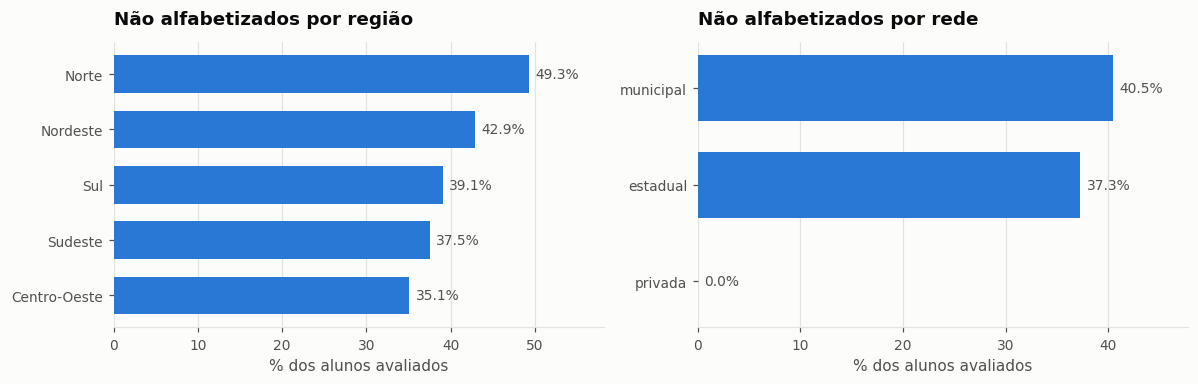

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))

reg = alvo_por["regiao"].sort_values("pct_nao_alfabetizado", ascending=False)
barras_horizontais(ax1, list(reg.index), list(reg["pct_nao_alfabetizado"]), formato="{:.1f}%")
ax1.set_title("Não alfabetizados por região")
ax1.set_xlabel("% dos alunos avaliados")

rede = alvo_por["rede"].sort_values("pct_nao_alfabetizado", ascending=False)
barras_horizontais(ax2, list(rede.index), list(rede["pct_nao_alfabetizado"]), formato="{:.1f}%")
ax2.set_title("Não alfabetizados por rede")
ax2.set_xlabel("% dos alunos avaliados")

fig.tight_layout()
salva(fig, "eda_alvo_regiao_rede.png")
plt.show()

A distribuição do alvo é **quase equilibrada** (~40% na classe positiva), o que dispensa
reamostragem sintética. O desequilíbrio relevante não é o global, e sim o territorial: entre
regiões a amplitude é de 14 pontos percentuais (Centro-Oeste 35,3% contra Norte 49,2%), e
entre UFs chega a 49 — de 14,7% no Ceará a 64,0% na Bahia (seção 6). A agregação regional
esconde o problema: é no estado que ele se decide. É o primeiro indício de que **o
território, não o aluno, carrega a maior parte do sinal**.

A rede quase não separa (municipal 40,6% contra estadual 37,1%), e a série é constante — a
avaliação é do 2º ano. Nenhum atributo da avaliação em si distingue as crianças.

## 3. O vazamento: por que `proficiencia` não pode entrar no modelo

O Indicador Criança Alfabetizada é definido por um corte determinístico:
`alfabetizado := proficiencia >= 743`. Se `proficiencia` entrar como variável, o modelo
apenas redescobre o limiar e devolve métricas perfeitas — sem qualquer valor preditivo,
porque a proficiência **é o resultado da avaliação**, conhecida no mesmo instante do alvo.

In [6]:
viola = con.execute(f"""
    SELECT COUNT(*) FROM read_parquet('{BASE_ALUNOS}')
    WHERE nao_alfabetizado <> CASE WHEN proficiencia >= 743 THEN 1 ELSE 0 END
""").fetchone()[0]
print(f"registros que violam a regra 'proficiencia >= 743': {viola:,} de "
      f"{resumo.loc[0, 'alunos']:,} — a regra e exata")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

registros que violam a regra 'proficiencia >= 743': 1,851,852 de 1,851,852 — a regra e exata


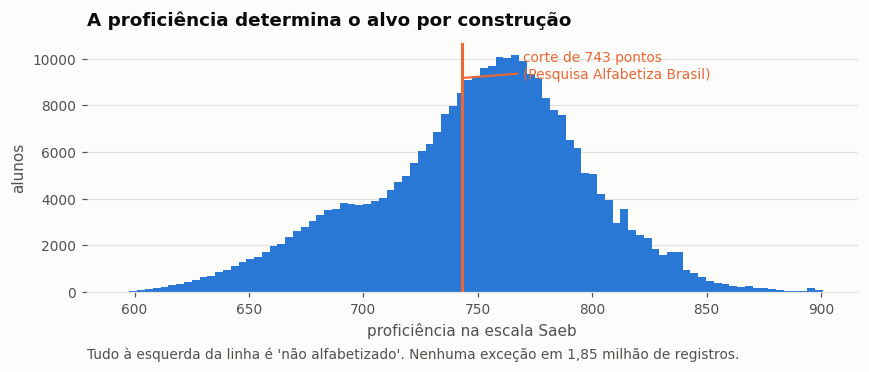

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.hist(df["proficiencia"].dropna(), bins=90, color=AZUL, edgecolor=None)
ax.axvline(743, color=LARANJA, linewidth=2)
ax.annotate("corte de 743 pontos\n(Pesquisa Alfabetiza Brasil)", xy=(743, ax.get_ylim()[1] * 0.86),
            xytext=(770, ax.get_ylim()[1] * 0.86), color=LARANJA, fontsize=9,
            arrowprops=dict(arrowstyle="-", color=LARANJA, linewidth=1.4))
ax.set_title("A proficiência determina o alvo por construção")
ax.set_xlabel("proficiência na escala Saeb")
ax.set_ylabel("alunos")
limpa_eixos(ax)
anota(ax, "Tudo à esquerda da linha é 'não alfabetizado'. Nenhuma exceção em 1,85 milhão de registros.")
fig.tight_layout()
salva(fig, "eda_leakage_proficiencia.png")
plt.show()

A mesma lógica condena os **agregados do próprio ano**: a taxa municipal de 2024 é a média
do alvo dos colegas do mesmo município; a média de português de 2024 é a média da variável
que define o alvo. Todos saem. O que sobra como contexto legítimo é o **ano anterior**.

### 3.1 Um vazamento mais sutil: colunas estáticas

Nem toda coluna filtrada por `ano = 2023` é de fato de 2023. Algumas colunas foram agregadas
por município **sem o ano** e, por isso, têm o mesmo valor nos dois anos — e podem
carregar informação de 2024.

O teste: uma feature estática só é aceitável se sua relação com o futuro for **mediada pelo
passado**, isto é, `corr(X, taxa_2024) <= corr(X, taxa_2023)`. A própria persistência da
taxa serve de régua.

In [8]:
# taxa observada em cada ano (Gold municipal) x colunas estáticas (Gold de metas)
cands = ["nivel_alfabetizacao", "percentual_participacao",
         "meta_alfabetizacao_2024", "meta_alfabetizacao_2030"]
sel = []
for f in cands:
    sel += [f'ROUND(CORR(m.{f}, a.t23), 4) AS "{f}|com taxa 2023"',
            f'ROUND(CORR(m.{f}, b.t24), 4) AS "{f}|com taxa 2024"']

BASE_DIAG = f"""
    WITH a AS (SELECT id_municipio, rede, AVG(taxa_alfabetizacao) t23
               FROM read_parquet('{GOLD_MUNICIPIO}', hive_partitioning=true)
               WHERE ano = {ANO_CONTEXTO} GROUP BY 1, 2),
         b AS (SELECT id_municipio, rede, AVG(taxa_alfabetizacao) t24
               FROM read_parquet('{GOLD_MUNICIPIO}', hive_partitioning=true)
               WHERE ano = {ANO_ALVO} GROUP BY 1, 2),
         m AS (SELECT * FROM read_parquet('{GOLD_METAS}'))
    SELECT %s
    FROM a JOIN b USING (id_municipio, rede) JOIN m USING (id_municipio, rede)
"""

diag = con.execute(BASE_DIAG % ", ".join(sel)).df().T
diag.columns = ["correlacao"]
diag.index = pd.MultiIndex.from_tuples([tuple(i.split("|")) for i in diag.index],
                                       names=["feature", "contra"])
regua = con.execute(BASE_DIAG % "ROUND(CORR(a.t23, b.t24), 4)").fetchone()[0]
display(diag.unstack("contra")["correlacao"])
print(f"regua — persistencia da propria taxa: corr(taxa_2023, taxa_2024) = {regua}")

contra,com taxa 2023,com taxa 2024
feature,,
meta_alfabetizacao_2024,0.9374,0.6062
meta_alfabetizacao_2030,NaN,NaN
nivel_alfabetizacao,0.8343,0.8562
percentual_participacao,0.2475,0.3634


regua — persistencia da propria taxa: corr(taxa_2023, taxa_2024) = 0.6197


contra,com taxa 2023,com taxa 2024,veredito
feature,,,
meta_alfabetizacao_2024,0.9374,0.6062,OK — mediada pelo passado
nivel_alfabetizacao,0.8343,0.8562,VAZA — antecipa o alvo
percentual_participacao,0.2475,0.3634,VAZA — antecipa o alvo


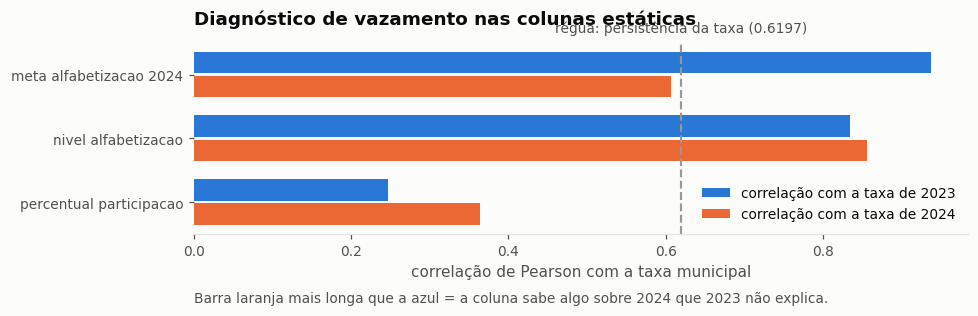

In [9]:
comp = diag.unstack("contra")["correlacao"].dropna()
comp["veredito"] = np.where(comp["com taxa 2024"] > comp["com taxa 2023"],
                            "VAZA — antecipa o alvo", "OK — mediada pelo passado")
display(comp)

fig, ax = plt.subplots(figsize=(9, 3.2))
y = np.arange(len(comp))
ax.barh(y - 0.19, comp["com taxa 2023"], height=0.34, color=AZUL, label=f"correlação com a taxa de {ANO_CONTEXTO}")
ax.barh(y + 0.19, comp["com taxa 2024"], height=0.34, color=LARANJA, label=f"correlação com a taxa de {ANO_ALVO}")
ax.axvline(regua, color=NEUTRO, linewidth=1.4, linestyle="--")
ax.text(regua, -0.62, f"régua: persistência da taxa ({regua})", color=TINTA_SEC,
        fontsize=9, va="bottom", ha="center")
ax.set_yticks(y, [i.replace("_", " ") for i in comp.index])
ax.invert_yaxis()
ax.set_title("Diagnóstico de vazamento nas colunas estáticas")
ax.set_xlabel("correlação de Pearson com a taxa municipal")
limpa_eixos(ax)
ax.grid(axis="y", visible=False)
ax.legend(loc="lower right")
anota(ax, "Barra laranja mais longa que a azul = a coluna sabe algo sobre 2024 que 2023 não explica.", y=-0.30)
fig.tight_layout()
salva(fig, "eda_diagnostico_vazamento.png")
plt.show()

Duas colunas reprovam e saem do modelo:

| Coluna | corr. com 2023 | corr. com 2024 | Decisão |
|---|---|---|---|
| `nivel_alfabetizacao` | 0,834 | **0,856** | vetada — o nível do INEP foi recalibrado com o resultado de 2024 |
| `percentual_participacao` | 0,248 | **0,363** | vetada — é a participação registrada na coleta de 2024 |
| `meta_alfabetizacao_2024` | 0,937 | 0,606 | mantida — relação com o futuro mediada pelo passado |
| `meta_alfabetizacao_2030` | — | — | vetada por outro motivo: constante em 80,0 (variância zero) |

`nivel_alfabetizacao` era, de longe, a variável mais importante nas primeiras rodadas do
modelo. Removê-la custou **0,001 de PR-AUC** — porque ela já era 83% redundante com a taxa
de 2023, e o restante era vazamento. Esse é o resultado que justifica o esforço do
diagnóstico: uma variável aparentemente excelente que não entregaria nada em produção.

Os vetos ficam registrados em `src.config.COLUNAS_VETADAS_DIAGNOSTICO`, com a justificativa
de cada um.

In [10]:
for coluna, motivo in COLUNAS_VETADAS_DIAGNOSTICO.items():
    print(f"· {coluna}\n    {motivo}\n")

· mun_ctx_nivel_alfabetizacao
    corr com taxa_2024 (0,856) > corr com taxa_2023 (0,834): o nivel do INEP foi recalibrado com o resultado de 2024, entao antecipa o alvo

· mun_ctx_percentual_participacao
    corr com taxa_2024 (0,363) > corr com taxa_2023 (0,248): a taxa de participacao registrada e a da coleta de 2024

· mun_meta_2030
    constante em 80,0 para todos os municipios — variancia zero

· uf_meta_2030
    constante em 80,0 para todas as UFs — variancia zero

· mun_esforco_anual_requerido
    derivada de meta_2030, que e constante; vira transformacao linear da taxa de 2023 e apenas duplica o sinal de mun_ctx_taxa_alfabetizacao



## 4. As variáveis que sobram

Com o vazamento removido, o conjunto de features é: atributos da avaliação do aluno,
contexto municipal e estadual **de 2023**, porte da rede e socioeconômico do IBGE.

In [11]:
print(f"{len(FEATURES)} features | {len(NUM_FEATURES)} numericas | {len(CAT_BAIXA)} categoricas curtas")
display(df[NUM_FEATURES].describe().T.round(2))

22 features | 15 numericas | 5 categoricas curtas


,count,mean,std,min,25%,50%,75%,max
peso_aluno,300000.0,1.14,0.21,1.00,1.03,1.09,1.19,29.83
mun_ctx_taxa_alfabetizacao,294433.0,56.64,15.55,3.41,46.67,56.17,65.96,100.00
mun_ctx_media_portugues,294433.0,745.60,20.10,673.30,733.88,743.25,754.15,868.46
mun_meta_2024,285954.0,59.16,12.41,7.94,49.80,59.20,68.18,80.00
mun_gap_projetado,285954.0,2.34,5.60,-61.27,1.50,3.82,5.45,71.19
uf_ctx_taxa_alfabetizacao,294774.0,56.44,10.90,31.30,51.91,52.20,61.38,84.46
uf_ctx_media_portugues,294774.0,745.37,14.43,713.13,737.30,741.60,751.71,795.68
uf_ctx_ranking_nacional,294774.0,11.47,6.15,1.00,7.00,13.00,15.00,24.00
escola_n_alunos_avaliados,300000.0,68.89,44.44,2.00,37.00,59.00,90.00,368.00
mun_n_alunos_avaliados,300000.0,8517.59,21347.88,8.00,315.00,1152.00,4293.00,94373.00


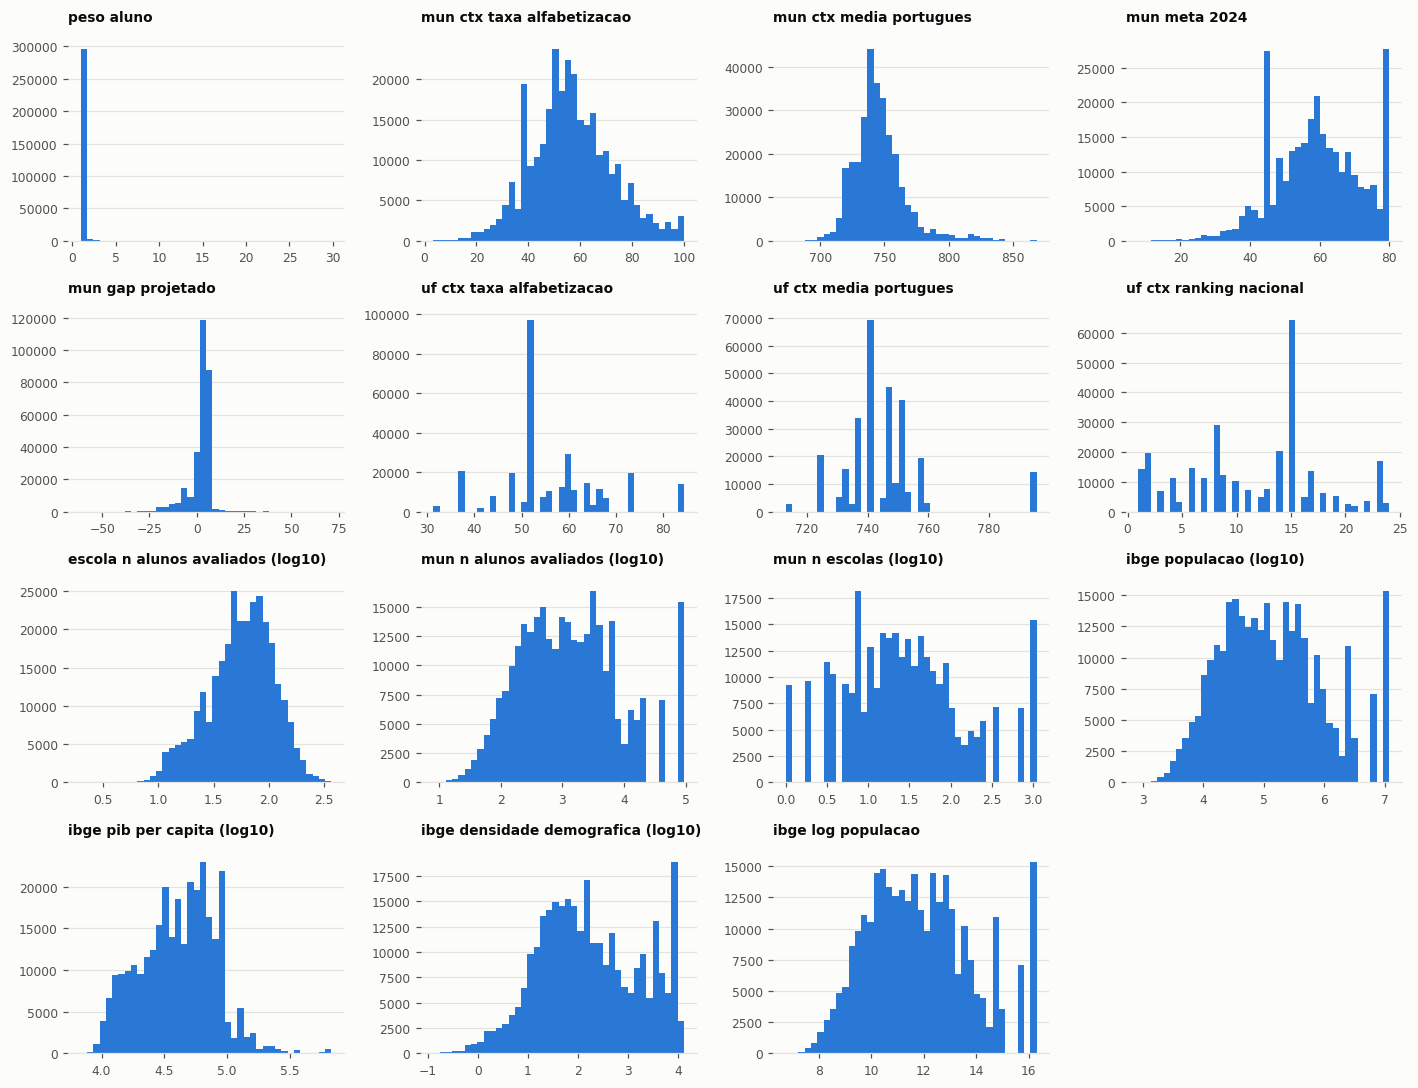

In [12]:
numericas = [c for c in NUM_FEATURES if df[c].notna().any()]
n = len(numericas)
fig, axes = plt.subplots((n + 3) // 4, 4, figsize=(13, 2.5 * ((n + 3) // 4)))
for ax, coluna in zip(axes.ravel(), numericas):
    serie = df[coluna].dropna()
    # população e PIB são fortemente assimétricos: em escala linear o histograma vira
    # uma barra só, então essas duas vão em log
    if coluna in ("ibge_populacao", "ibge_pib_per_capita", "ibge_densidade_demografica",
                  "escola_n_alunos_avaliados", "mun_n_alunos_avaliados", "mun_n_escolas"):
        serie, sufixo = np.log10(serie[serie > 0]), " (log10)"
    else:
        sufixo = ""
    ax.hist(serie, bins=40, color=AZUL)
    ax.set_title(coluna.replace("_", " ") + sufixo, fontsize=9)
    limpa_eixos(ax)
    ax.tick_params(labelsize=8)
for ax in axes.ravel()[n:]:
    ax.set_visible(False)
fig.tight_layout()
salva(fig, "eda_distribuicoes_numericas.png")
plt.show()

## 5. Correlações

Correlação de **Spearman**, não Pearson: várias variáveis são fortemente assimétricas
(população, PIB, contagens) e a relação de interesse é monotônica, não linear.

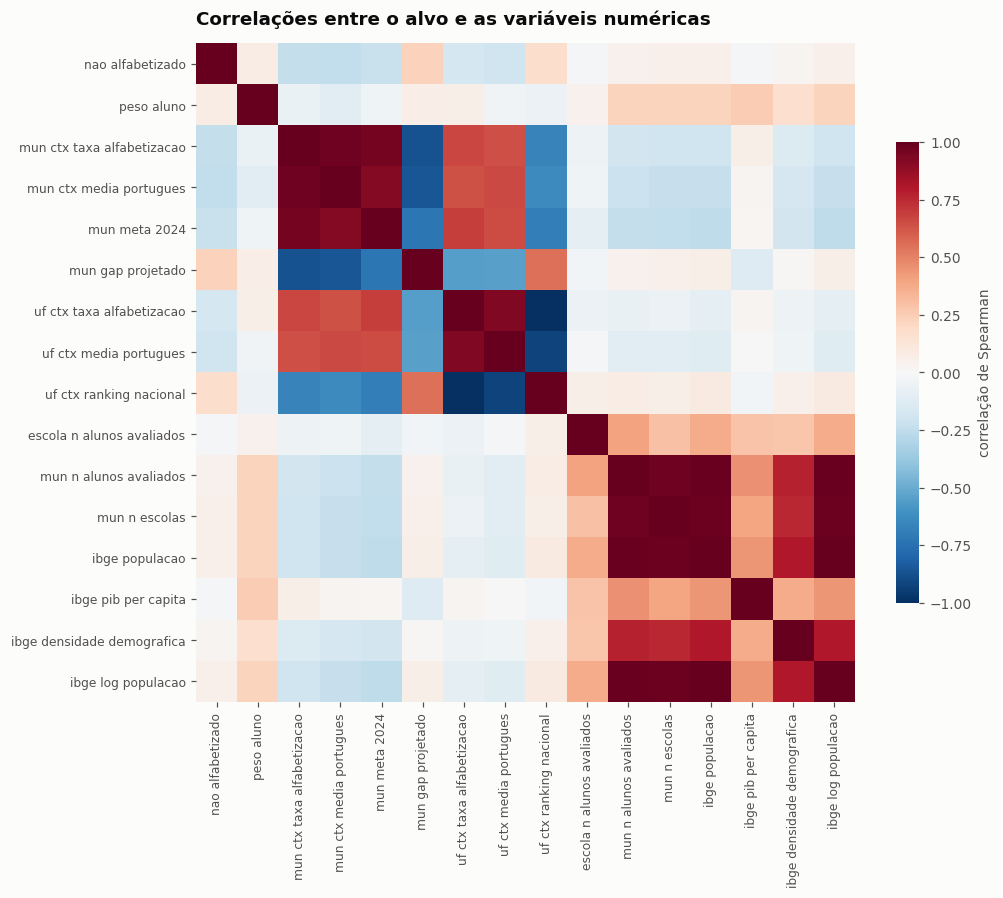

In [13]:
alvo_e_num = ["nao_alfabetizado"] + numericas
corr = df[alvo_e_num].corr(method="spearman")

fig, ax = plt.subplots(figsize=(9.5, 8))
im = ax.imshow(corr, cmap=DIVERGENTE, vmin=-1, vmax=1)
rotulos = [c.replace("_", " ") for c in alvo_e_num]
ax.set_xticks(range(len(rotulos)), rotulos, rotation=90, fontsize=8)
ax.set_yticks(range(len(rotulos)), rotulos, fontsize=8)
ax.grid(False)
for lado in ("top", "right", "left", "bottom"):
    ax.spines[lado].set_visible(False)
cb = fig.colorbar(im, ax=ax, shrink=0.7)
cb.set_label("correlação de Spearman", fontsize=9)
cb.outline.set_visible(False)
ax.set_title("Correlações entre o alvo e as variáveis numéricas")
fig.tight_layout()
salva(fig, "eda_correlacoes.png")
plt.show()

In [14]:
com_alvo = (corr["nao_alfabetizado"].drop("nao_alfabetizado")
            .sort_values(key=abs, ascending=False).round(3))
display(com_alvo.to_frame("spearman_com_alvo"))

,spearman_com_alvo
mun_ctx_media_portugues,-0.248
mun_ctx_taxa_alfabetizacao,-0.239
mun_gap_projetado,0.228
mun_meta_2024,-0.220
uf_ctx_media_portugues,-0.202
uf_ctx_taxa_alfabetizacao,-0.180
uf_ctx_ranking_nacional,0.180
peso_aluno,0.076
mun_n_escolas,0.052
ibge_populacao,0.047


Nenhuma variável isolada passa de correlação moderada com o alvo — o que já antecipa o
teto de desempenho do modelo. As mais fortes são todas de **contexto municipal**: a taxa de
alfabetização do município no ano anterior e a média de português. Variáveis do aluno
(`peso_aluno`, `caderno`) são praticamente ruído, porque os microdados públicos do INEP
**não trazem atributos individuais** — não há renda familiar, frequência, escolaridade dos
pais ou trajetória escolar. Essa é a limitação estrutural do projeto.

,cramers_v_com_alvo
sigla_uf,0.2351
regiao,0.0812
rede,0.0218
caderno,0.0117
serie,NaN


sem variância, fora do gráfico: serie


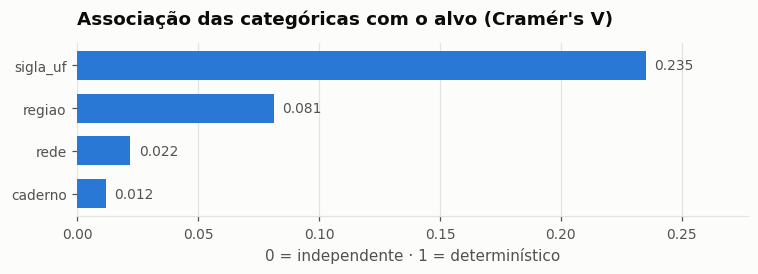

In [15]:
# Associação entre categóricas e o alvo — Cramér's V, apropriado para variáveis nominais
def cramers_v(x, y):
    tabela = pd.crosstab(x, y).to_numpy()
    chi2 = ((tabela - tabela.sum(1, keepdims=True) * tabela.sum(0, keepdims=True) / tabela.sum()) ** 2
            / (tabela.sum(1, keepdims=True) * tabela.sum(0, keepdims=True) / tabela.sum())).sum()
    n = tabela.sum()
    return float(np.sqrt((chi2 / n) / (min(tabela.shape) - 1)))

assoc = pd.Series({c: cramers_v(df[c], df["nao_alfabetizado"]) for c in CAT_BAIXA}
                  ).sort_values(ascending=False).round(4)
display(assoc.to_frame("cramers_v_com_alvo"))

# `serie` é constante nesta base (só o 2º ano é avaliado), então o Cramér's V é
# indefinido — a coluna sai do gráfico em vez de virar uma barra vazia
constantes = assoc[assoc.isna()].index.tolist()
if constantes:
    print("sem variância, fora do gráfico:", ", ".join(constantes))
assoc = assoc.dropna()

fig, ax = plt.subplots(figsize=(7, 2.6))
barras_horizontais(ax, list(assoc.index), list(assoc.values), formato="{:.3f}")
ax.set_title("Associação das categóricas com o alvo (Cramér's V)")
ax.set_xlabel("0 = independente · 1 = determinístico")
fig.tight_layout()
salva(fig, "eda_cramers_v.png")
plt.show()

`sigla_uf` é a categórica mais associada ao alvo — bem acima de `rede`, `serie` e `caderno`.
Confirma o padrão: **onde a criança estuda pesa mais do que qualquer atributo registrado
sobre ela**.

## 6. Território: o mapa da desigualdade

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,sigla_uf,regiao,alunos,pct_nao_alfabetizado,taxa_2023
0,BA,Nordeste,104069,64.0,37.0
1,SE,Nordeste,17802,61.4,31.0
2,RN,Nordeste,22848,60.0,37.4
3,RS,Sul,89562,54.2,64.3
4,AP,Norte,11214,52.7,41.9
5,PA,Norte,83193,51.2,48.4
6,AL,Nordeste,31575,51.1,43.9
7,AM,Norte,46628,50.2,52.3
8,TO,Norte,16823,49.9,43.2
9,AC,Norte,10234,48.1,NaN


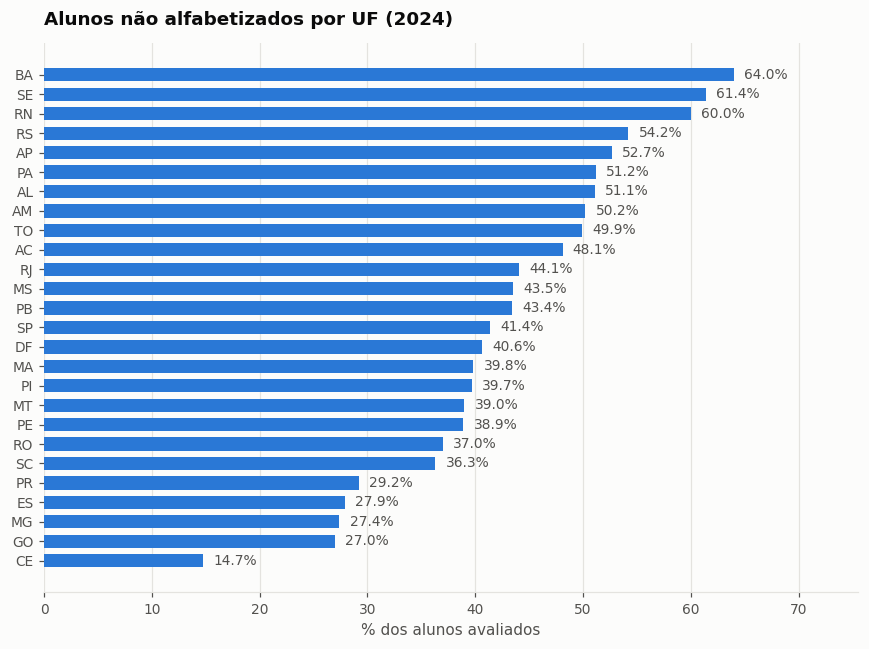

In [16]:
uf = con.execute(f"""
    SELECT sigla_uf, regiao, COUNT(*) AS alunos,
           ROUND(100 * AVG(nao_alfabetizado), 1) AS pct_nao_alfabetizado,
           ROUND(AVG(mun_ctx_taxa_alfabetizacao), 1) AS taxa_2023
    FROM read_parquet('{BASE_ALUNOS}')
    WHERE sigla_uf IS NOT NULL
    GROUP BY 1, 2 ORDER BY pct_nao_alfabetizado DESC
""").df()
display(uf)

fig, ax = plt.subplots(figsize=(8, 6))
barras_horizontais(ax, list(uf["sigla_uf"]), list(uf["pct_nao_alfabetizado"]), formato="{:.1f}%")
ax.set_title(f"Alunos não alfabetizados por UF ({ANO_ALVO})")
ax.set_xlabel("% dos alunos avaliados")
fig.tight_layout()
salva(fig, "eda_uf_ranking.png")
plt.show()

### 6.1 O caso do Rio Grande do Sul

Ao cruzar 2023 e 2024, uma UF se descola de todas as outras.

,pares,taxa_2023,taxa_2024,pct_nao_atingiu,variacao_pp
sigla_uf,,,,,
RS,1080,73.8,54.2,89.2,-19.6
PR,795,75.9,74.1,53.6,-1.8
AM,136,53.4,52.1,54.4,-1.3
BA,794,37.6,36.6,80.7,-1.0
CE,376,89.8,90.2,8.8,0.4
SC,580,66.8,68.2,47.1,1.4
MA,435,61.4,63.4,48.0,2.0
PA,282,46.9,49.5,66.0,2.6
RO,113,64.5,67.2,47.8,2.7


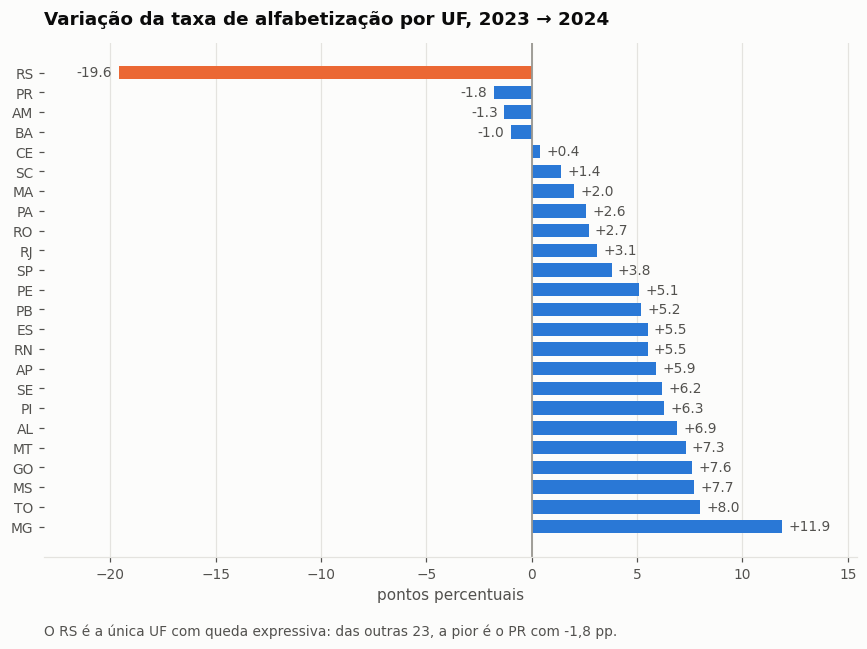

In [17]:
mun = pd.read_parquet(BASE_MUNICIPAL)
evolucao = (mun.groupby("sigla_uf")
            .agg(pares=("nao_atingiu_meta", "size"),
                 taxa_2023=("ctx_taxa", "mean"),
                 taxa_2024=("taxa_observada", "mean"),
                 pct_nao_atingiu=("nao_atingiu_meta", "mean"))
            .assign(variacao_pp=lambda d: (d.taxa_2024 - d.taxa_2023).round(1),
                    pct_nao_atingiu=lambda d: (100 * d.pct_nao_atingiu).round(1),
                    taxa_2023=lambda d: d.taxa_2023.round(1),
                    taxa_2024=lambda d: d.taxa_2024.round(1))
            .sort_values("variacao_pp"))
display(evolucao)

fig, ax = plt.subplots(figsize=(8, 6))
cores = {"RS": LARANJA}
barras_horizontais(ax, list(evolucao.index), list(evolucao["variacao_pp"]),
                   formato="{:+.1f}", destaque=cores)
ax.set_title("Variação da taxa de alfabetização por UF, 2023 → 2024")
ax.set_xlabel("pontos percentuais")
anota(ax, "O RS é a única UF com queda expressiva: das outras 23, a pior é o PR com -1,8 pp.", y=-0.13)
fig.tight_layout()
salva(fig, "eda_variacao_uf.png")
plt.show()

In [18]:
rs = con.execute(f"""
    SELECT ano, COUNT(*) AS alunos, COUNT(DISTINCT id_municipio) AS municipios,
           COUNT(DISTINCT id_escola) AS escolas,
           ROUND(AVG(proficiencia), 1) AS proficiencia_media,
           ROUND(100 * AVG(CASE WHEN alfabetizado_flag THEN 1.0 ELSE 0 END), 1) AS pct_alfabetizado
    FROM read_parquet('{GOLD_ALUNO}', hive_partitioning=true)
    WHERE sigla_uf = 'RS'
    GROUP BY 1 ORDER BY 1
""").df()
display(rs)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,ano,alunos,municipios,escolas,proficiencia_media,pct_alfabetizado
0,2023,98660,488,3387,748.5,64.7
1,2024,89562,479,3284,735.6,45.8


A cobertura do RS é estável (mesmos municípios, escolas e volume de alunos) e a queda é
**uniforme entre as redes estadual e municipal**. O que muda é a proficiência média:
748,5 → 735,6. Como o corte está em 743, a média cruzou o limiar, e um deslocamento de 13
pontos na escala virou 19 pontos percentuais no indicador.

Isso é o efeito de um corte binário posicionado perto do centro da distribuição — uma
propriedade do indicador, não um erro. Mas uma variação dessa magnitude em uma UF inteira,
em um ano, merece verificação junto ao INEP antes de embasar decisão de política pública.
**Fica registrada como limitação do projeto.**

## 7. Socioeconômico: o que o IBGE acrescenta

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

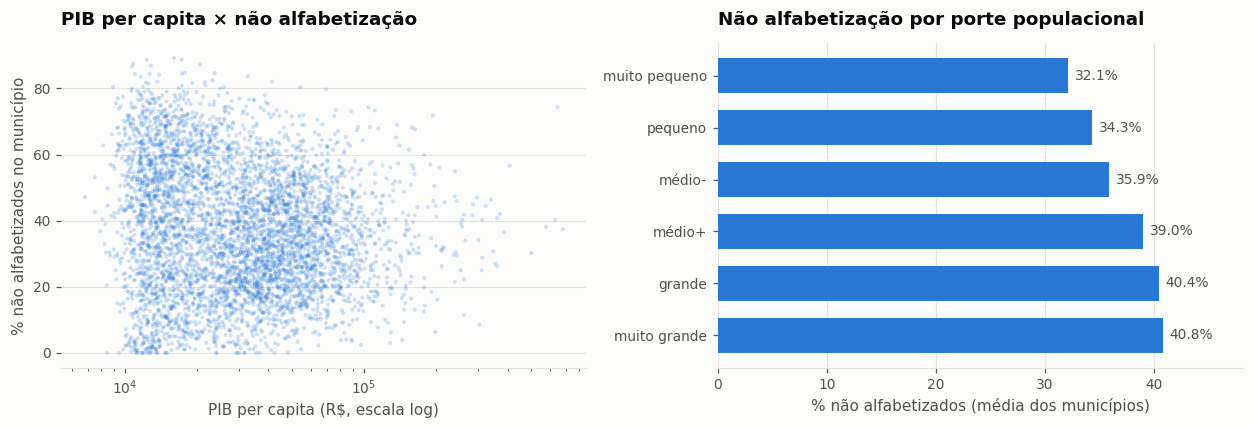

Spearman PIB per capita x nao alfabetizacao: -0.138
Spearman populacao x nao alfabetizacao: 0.187


In [19]:
perfil = con.execute(f"""
    SELECT id_municipio, ANY_VALUE(regiao) AS regiao,
           ANY_VALUE(ibge_pib_per_capita) AS pib_per_capita,
           ANY_VALUE(ibge_populacao) AS populacao,
           100 * AVG(nao_alfabetizado) AS pct_nao_alfabetizado,
           COUNT(*) AS alunos
    FROM read_parquet('{BASE_ALUNOS}')
    WHERE ibge_pib_per_capita IS NOT NULL
    GROUP BY 1 HAVING COUNT(*) >= 30
""").df()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4))
ax1.scatter(perfil["pib_per_capita"], perfil["pct_nao_alfabetizado"],
            s=7, alpha=0.22, color=AZUL, edgecolors="none")
ax1.set_xscale("log")
ax1.set_title("PIB per capita × não alfabetização")
ax1.set_xlabel("PIB per capita (R$, escala log)")
ax1.set_ylabel("% não alfabetizados no município")
limpa_eixos(ax1)

faixas = pd.qcut(perfil["populacao"], 6,
                 labels=["muito pequeno", "pequeno", "médio-", "médio+", "grande", "muito grande"])
por_faixa = perfil.groupby(faixas, observed=True)["pct_nao_alfabetizado"].mean().round(1)
barras_horizontais(ax2, list(por_faixa.index.astype(str)), list(por_faixa.values), formato="{:.1f}%")
ax2.set_title("Não alfabetização por porte populacional")
ax2.set_xlabel("% não alfabetizados (média dos municípios)")

fig.tight_layout()
salva(fig, "eda_socioeconomico.png")
plt.show()

print("Spearman PIB per capita x nao alfabetizacao:",
      round(perfil["pib_per_capita"].corr(perfil["pct_nao_alfabetizado"], method="spearman"), 3))
print("Spearman populacao x nao alfabetizacao:",
      round(perfil["populacao"].corr(perfil["pct_nao_alfabetizado"], method="spearman"), 3))

## 8. Persistência: quanto 2023 explica 2024

A pergunta que sustenta todo o desenho preditivo — se a taxa municipal do ano anterior não
tivesse poder explicativo, não haveria modelo possível com as variáveis disponíveis.

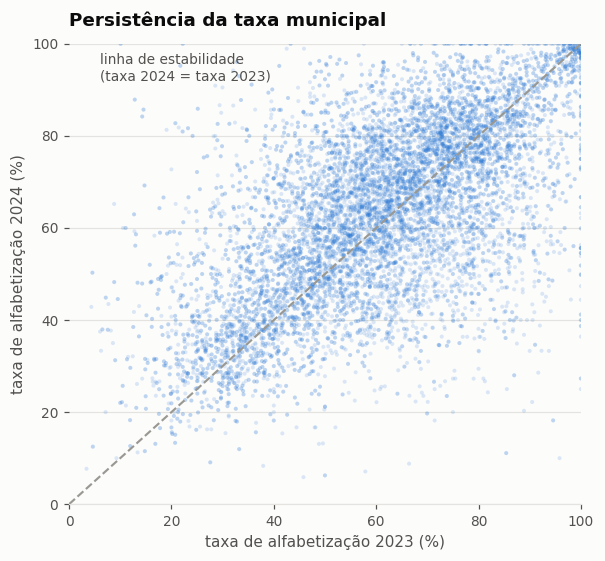

Spearman entre a taxa de 2023 e a de 2024: 0.611
pares (municipio, rede): 10,806


In [20]:
persistencia = mun.dropna(subset=["ctx_taxa", "taxa_observada"])
fig, ax = plt.subplots(figsize=(5.6, 5.2))
ax.scatter(persistencia["ctx_taxa"], persistencia["taxa_observada"],
           s=7, alpha=0.16, color=AZUL, edgecolors="none")
lim = [0, 100]
ax.plot(lim, lim, color=NEUTRO, linewidth=1.4, linestyle="--")
ax.text(6, 92, "linha de estabilidade\n(taxa 2024 = taxa 2023)", color=TINTA_SEC, fontsize=9)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_title("Persistência da taxa municipal")
ax.set_xlabel(f"taxa de alfabetização {ANO_CONTEXTO} (%)")
ax.set_ylabel(f"taxa de alfabetização {ANO_ALVO} (%)")
limpa_eixos(ax)
fig.tight_layout()
salva(fig, "eda_persistencia.png")
plt.show()

r = persistencia["ctx_taxa"].corr(persistencia["taxa_observada"], method="spearman")
print(f"Spearman entre a taxa de {ANO_CONTEXTO} e a de {ANO_ALVO}: {r:.3f}")
print(f"pares (municipio, rede): {len(persistencia):,}")

A correlação é **moderada, não forte**. Municípios mudam de patamar entre um ciclo e outro,
e a nuvem é larga em torno da diagonal. Isso define, sozinho, o teto realista do modelo:
o contexto municipal do ano anterior orienta, mas não determina, o resultado do ano seguinte.

## 9. Hipóteses analíticas

Cada hipótese abaixo nasceu de um achado desta análise e determina uma decisão concreta de
modelagem, verificável nos notebooks 02 e 03.

| # | Hipótese | Evidência na EDA | Decisão de modelagem |
|---|---|---|---|
| **H1** | `proficiencia` e os agregados do mesmo ano determinam o alvo e destruiriam a validade do modelo | Seção 3: zero violações da regra dos 743 pontos em 1,85 M registros | Excluídas do conjunto de features; um **teste anti-leakage** no notebook 02 reintroduz `proficiencia` e mostra ROC-AUC ≈ 1,0 |
| **H2** | Colunas estáticas por município podem vazar o ano-alvo mesmo filtradas por `ano = 2023` | Seção 3.1: `nivel_alfabetizacao` correlaciona mais com 2024 (0,856) que com 2023 (0,834) | Vetadas via `COLUNAS_VETADAS_DIAGNOSTICO`; o custo em PR-AUC (0,001) confirma que eram redundantes |
| **H3** | O contexto territorial explica mais do que qualquer atributo individual disponível | Seções 5 e 6: `sigla_uf` lidera o Cramér's V; `peso_aluno` e `caderno` são ruído | Features majoritariamente municipais/estaduais; `TargetEncoder` em `id_municipio` e `id_escola` |
| **H4** | O desempenho num município sem histórico é menor que num município conhecido | Seção 8: a persistência da taxa é moderada | Avaliação em **dois regimes**: holdout aleatório e holdout agrupado por município |
| **H5** | Variáveis socioeconômicas do IBGE acrescentam sinal além do histórico educacional | Seção 7: PIB per capita e porte populacional se associam à taxa | IBGE entra como bloco de features; a `permutation_importance` mede o ganho real |
| **H6** | O teto de desempenho é baixo porque faltam atributos do aluno | Seção 5: nenhuma correlação individual passa de moderada | O sucesso do projeto é medido por **priorização** (ranking municipal), não por acurácia individual |

### O que a EDA já decide

- **Métrica principal: PR-AUC** sobre a classe "não alfabetizado", com recall como métrica
  operacional. Acurácia é enganosa numa base 60/40 com sinal fraco.
- **Sem reamostragem sintética**: 40% de prevalência não é desbalanceamento; `class_weight`
  balanceado é suficiente e não distorce as probabilidades.
- **Imputação com indicador de ausência**: a falta de contexto de 2023 marca redes recém
  integradas ao programa e é informativa.
- **Dois modelos, não um**: o modelo por aluno responde "quem está em risco"; o modelo
  municipal (notebook 03) responde "onde agir" — que é a pergunta do gestor.

In [21]:
con.close()
print("EDA concluida — figuras em reports/images/")

EDA concluida — figuras em reports/images/
